In [1]:
from preprocessing import get_data, get_encoded_data, split_data, create_features

features, target = get_data()
features = create_features(features)
encoded_features, target = get_encoded_data(features, target)
X_train, X_valid, X_test, y_train, y_valid, y_test = split_data(encoded_features, target)

In [6]:
y_train.value_counts()

churn
0    4471
1    1154
Name: count, dtype: int64

In [2]:
from xgboost import XGBClassifier


model = XGBClassifier(
    n_estimators=850,
    max_depth=3,
    learning_rate=0.01,
    scale_pos_weight=4,
    random_state=42,
    objective='binary:logistic',
    tree_method='approx',
)

model.fit(X_train, y_train)
valid_pred = model.predict(X_valid)
valid_pred_proba = model.predict_proba(X_valid)[:, 1]


In [3]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

accuracy = accuracy_score(y_valid, valid_pred)
f1 = f1_score(y_valid, valid_pred)
recall = recall_score(y_valid, valid_pred)
precision = precision_score(y_valid, valid_pred)

print(f"Validation 성능 - Accuracy: {accuracy:.4f}, F1 Score: {f1:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}")

Validation 성능 - Accuracy: 0.7973, F1 Score: 0.6107, Recall: 0.7720, Precision: 0.5051


/Users/tera/Desktop/workspace/skn_21/project/project_02/.venv/lib/python3.13/site-packages/sklearn/utils/_plotting.py:379: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


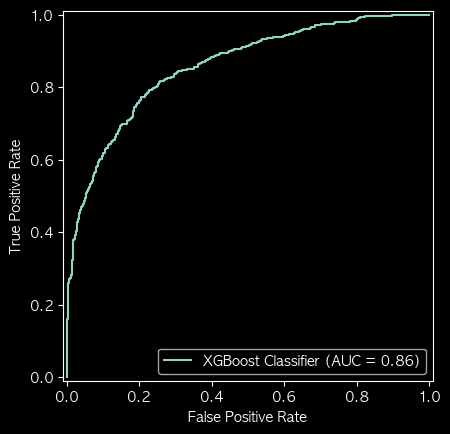

In [72]:

from sklearn.metrics import roc_curve, RocCurveDisplay, roc_auc_score

rfc_roc = roc_auc_score(y_valid, valid_pred_proba)
fpr, recall, thresh = roc_curve(y_valid, valid_pred_proba)
disp_roc_rfc = RocCurveDisplay(
    fpr=fpr, tpr=recall,
    roc_auc=rfc_roc,
    estimator_name='XGBoost Classifier'
)
disp_roc_rfc.plot()
